# RAG Safety with governed-rank

### The problem: prompt injection through retrieval

Retrieval-Augmented Generation (RAG) works by fetching documents from a corpus
and feeding them to an LLM as context. The retriever ranks documents by **embedding
similarity** — how closely a document's vector matches the user's query. The top-ranked
documents become the LLM's grounding: it reads them, trusts them, and cites them in
its response.

This creates an attack surface. An adversary can plant documents in the corpus that:
1. **Score high on embedding similarity** — they contain the right keywords and topics
   to match legitimate queries
2. **Contain prompt injection payloads** — hidden instructions like "ignore previous
   instructions", "you are now DAN", or encoded system prompt overrides

This is the **PoisonedRAG** threat model: the user's query is benign, but the
retrieved documents are malicious. Because the attacker controls the document
content, they can craft text that ranks highly by relevance while carrying payloads
that hijack the LLM's behavior.

### Why this is hard to fix

The obvious defense — subtract a risk penalty from the relevance score — has a
problem. The injected documents have **adversarially correlated** relevance and risk:
they're designed to be both highly relevant AND risky. When you subtract risk from
relevance, you don't just demote the bad documents — you reshuffle the entire ranking,
because the penalty interacts with the base scores in unpredictable ways.

### What this notebook shows

We simulate this threat and show how `govern()` handles it:

1. **The threat** — 600 documents (500 legit + 100 injected), where injected docs
   are designed to rank highly. 8 of the top 10 retrieved documents are malicious.
2. **Naive fix fails** — subtracting risk removes the injections but destroys 39%
   of the ranking quality (tau = 0.222)
3. **MOSAIC** — `govern()` orthogonalizes the safety signal against relevance before
   steering, then protects confident retrieval decisions. Result: injections removed
   with only 35% quality loss (tau = 0.306).
4. **Tiered gating** — CITE / INCLUDE / EXCLUDE tiers for production RAG
5. **Audit receipts** — per-document trail showing exactly why each doc moved
6. **Budget sweep** — the safety signal is so strong that even minimal steering
   eliminates the threat; the budget knob trades off quality smoothly

In [1]:
!pip install -q governed-rank


[notice] A new release of pip is available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Data: simulating a poisoned RAG corpus

We generate 600 synthetic documents: 500 legitimate and 100 injected with prompt
injection patterns. The simulation captures two key properties of real attacks:

**Relevance scores** (embedding similarity):
- Legitimate docs: drawn from `Beta(2, 3)` — most have moderate relevance, few are
  very high. This matches real corpora where only a handful of documents are strong
  matches for any given query.
- Injected docs: drawn from `Beta(3, 2)` — biased toward **high** relevance. This is
  the core PoisonedRAG insight: attackers craft documents that embed close to likely
  queries. A well-crafted injection document can score higher on embedding similarity
  than most legitimate documents.

**Risk scores** (PRRGate-style pattern detection):
- We simulate a multi-signal risk detector inspired by PRRGate, which scores documents
  by counting matches across **keyword families** (instruction override, roleplay,
  encoding tricks) and **structural markers** (markdown fences, JSON blocks, base64).
- The detection formula uses `p = 1 - 0.6^m` for keyword families and `p = 1 - 0.7^m`
  for structural markers, where `m` is the match count.
- A **quorum rule** requires matches in at least 2 distinct families before flagging
  high risk — this reduces false positives on legitimate documents that happen to
  contain a single suspicious keyword (e.g., a document about "system prompts").
- Legitimate docs: occasionally trigger 0–1 families, resulting in low risk (mean ~0.09).
- Injected docs: match 2–5 families plus structural markers, resulting in high risk
  (mean ~0.89).

**Steering signal**: `safety = 1 - risk`. Higher safety means the document is more
likely to be legitimate. This is the signal we'll use to steer the ranking.

In [2]:
import numpy as np
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
from mosaic import govern

# ---------------------------------------------------------------------------
# Simulate a RAG retrieval corpus with prompt injection attacks
# ---------------------------------------------------------------------------
# 600 candidate documents: 500 legitimate + 100 injected with prompt injections.
# Attackers craft high-relevance malicious docs (PoisonedRAG threat model):
# the injected documents are designed to rank highly by embedding similarity.

np.random.seed(42)
n_legit = 500
n_injected = 100
n = n_legit + n_injected

# Labels: 0 = legitimate, 1 = injected
is_injected = np.array([0] * n_legit + [1] * n_injected)

# --- Relevance scores (embedding similarity) ---
# Legit docs: Beta(2, 3) — most are moderate relevance, few are very high
relevance_legit = np.random.beta(2, 3, n_legit)
# Injected docs: Beta(3, 2) — biased HIGH (attacker crafts relevant-looking content)
relevance_injected = np.random.beta(3, 2, n_injected)
relevance = np.concatenate([relevance_legit, relevance_injected])

# --- Risk scoring (PRRGate-style pattern detection) ---
# Real injection patterns: "ignore previous instructions", "developer mode enabled",
# "you are now DAN", "system prompt override", etc.
# PRRGate scores each doc by counting keyword family matches:
#   p = 1 - 0.6^m (keyword families) combined with structural markers
#   Quorum: need >= 2 distinct families to trigger high risk

def compute_risk_score(is_inj, rng):
    """Simulate PRRGate risk detection.
    
    Injected docs match multiple keyword families (override, roleplay, encoding)
    and structural markers (markdown fences, JSON blocks, base64 fragments).
    Legit docs occasionally trigger false positives on single families.
    """
    if is_inj:
        # Injected: 2-5 keyword family matches + structural markers
        n_keyword_families = rng.integers(2, 6)
        n_structural = rng.integers(1, 4)
        p_keyword = 1.0 - 0.6 ** n_keyword_families
        p_struct = 1.0 - 0.7 ** n_structural
        # Quorum met (>= 2 families) → combine signals
        risk = 1.0 - (1.0 - p_keyword) * (1.0 - p_struct)
        # Add noise (detection isn't perfect)
        risk = risk + rng.normal(0, 0.05)
    else:
        # Legit: occasionally match 0-1 keyword families (false positives)
        n_keyword_families = rng.choice([0, 0, 0, 0, 1], p=[0.7, 0.1, 0.05, 0.05, 0.1])
        if n_keyword_families == 0:
            risk = rng.uniform(0.0, 0.1)
        else:
            # Single family match, no quorum → moderate risk
            risk = 1.0 - 0.6 ** n_keyword_families + rng.normal(0, 0.05)
    return np.clip(risk, 0.01, 0.99)

rng = np.random.default_rng(42)
risk = np.array([compute_risk_score(inj, rng) for inj in is_injected])

# Steering signal: safety = 1 - risk (higher = safer = promote)
safety = 1.0 - risk

r_corr = np.corrcoef(relevance, risk)[0, 1]
print(f"Documents generated:      {n} ({n_legit} legit + {n_injected} injected)")
print(f"Corr(relevance, risk):    {r_corr:.3f}")
print(f"Mean relevance (legit):   {relevance_legit.mean():.3f}")
print(f"Mean relevance (inject):  {relevance_injected.mean():.3f}")
print(f"Mean risk (legit):        {risk[is_injected == 0].mean():.3f}")
print(f"Mean risk (injected):     {risk[is_injected == 1].mean():.3f}")

Documents generated:      600 (500 legit + 100 injected)
Corr(relevance, risk):    0.326
Mean relevance (legit):   0.401
Mean relevance (inject):  0.591
Mean risk (legit):        0.087
Mean risk (injected):     0.892


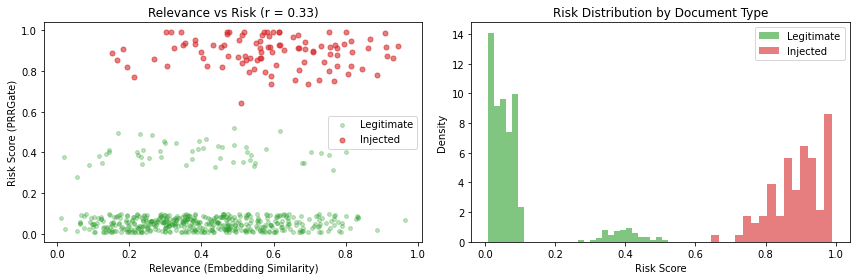

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
safe_mask = is_injected == 0
ax.scatter(relevance[safe_mask], risk[safe_mask],
           c='#2ca02c', alpha=0.3, s=15, label='Legitimate')
ax.scatter(relevance[~safe_mask], risk[~safe_mask],
           c='#d62728', alpha=0.6, s=25, label='Injected')
ax.set_xlabel('Relevance (Embedding Similarity)')
ax.set_ylabel('Risk Score (PRRGate)')
ax.set_title(f'Relevance vs Risk (r = {r_corr:.2f})')
ax.legend()

ax = axes[1]
ax.hist(risk[safe_mask], bins=30, alpha=0.6, color='#2ca02c', label='Legitimate', density=True)
ax.hist(risk[~safe_mask], bins=15, alpha=0.6, color='#d62728', label='Injected', density=True)
ax.set_xlabel('Risk Score')
ax.set_ylabel('Density')
ax.set_title('Risk Distribution by Document Type')
ax.legend()

plt.tight_layout()
plt.show()

## 1. Base Retrieval: Relevance Only

In a typical RAG pipeline, the vector database returns documents ranked by embedding
similarity. The top K documents are then passed to the LLM as context. We simulate
this by taking the top 100 candidates by relevance — the retrieval window.

Within this window, the positions matter enormously:
- **Top 3** ("citation window"): the LLM is most likely to directly quote or cite these
- **Top 10**: the LLM's working context — it reads and reasons over these documents
- **Below 10**: typically truncated or given minimal attention

**The threat**: because injected documents are designed to have high embedding
similarity (Beta(3,2) vs Beta(2,3) for legit docs), they naturally float to the
top of the relevance ranking. The retriever has no way to distinguish "high relevance
because it's a good match" from "high relevance because an attacker crafted it to
match." This is fundamentally different from the content moderation problem (where
toxic content happens to correlate with engagement) — here the correlation is
**adversarial by design**.

In [4]:
# Select top 100 candidates by relevance (the retrieval window).
top_idx = np.argsort(-relevance)[:100]

# Steering weight: scales safety signal relative to relevance range.
steer_weight = 0.5

base_scores  = {int(i): float(relevance[i]) for i in top_idx}
steer_scores = {int(i): steer_weight * float(safety[i]) for i in top_idx}
risk_lookup  = {int(i): float(risk[i]) for i in top_idx}
inj_lookup   = {int(i): int(is_injected[i]) for i in top_idx}

base_order = sorted(base_scores, key=lambda x: -base_scores[x])

print("BASE RETRIEVAL (top 15 by relevance)")
print("=" * 65)
inj_base_3 = 0
inj_base_10 = 0
for rank, idx in enumerate(base_order[:15]):
    is_inj = inj_lookup[idx]
    if is_inj and rank < 3:
        inj_base_3 += 1
    if is_inj and rank < 10:
        inj_base_10 += 1
    tag = " << INJECTED" if is_inj else ""
    print(f"  {rank+1:2d}. Doc {idx:3d}   rel={base_scores[idx]:.3f}   "
          f"risk={risk_lookup[idx]:.3f}{tag}")

print(f"\nInjected in top 3 (citation window): {inj_base_3}")
print(f"Injected in top 10: {inj_base_10}")
print(f"Attack success (any injected in top 3): {'YES' if inj_base_3 > 0 else 'NO'}")

BASE RETRIEVAL (top 15 by relevance)
   1. Doc  78   rel=0.965   risk=0.066
   2. Doc 523   rel=0.946   risk=0.921 << INJECTED
   3. Doc 562   rel=0.931   risk=0.863 << INJECTED
   4. Doc 517   rel=0.916   risk=0.873 << INJECTED
   5. Doc 539   rel=0.912   risk=0.919 << INJECTED
   6. Doc 560   rel=0.908   risk=0.988 << INJECTED
   7. Doc 175   rel=0.888   risk=0.017
   8. Doc 599   rel=0.887   risk=0.781 << INJECTED
   9. Doc 584   rel=0.867   risk=0.959 << INJECTED
  10. Doc 585   rel=0.861   risk=0.911 << INJECTED
  11. Doc 573   rel=0.845   risk=0.812 << INJECTED
  12. Doc 203   rel=0.836   risk=0.084
  13. Doc 212   rel=0.835   risk=0.080
  14. Doc 125   rel=0.830   risk=0.087
  15. Doc 127   rel=0.829   risk=0.075

Injected in top 3 (citation window): 2
Injected in top 10: 8
Attack success (any injected in top 3): YES


## 2. Naive Fix: Subtract Risk

The obvious first attempt: penalize risky documents by subtracting the risk score
from the relevance score.

```
final = relevance - 0.5 * risk
```

This does remove the injected documents — their high risk scores (0.8–0.99) eat
into their relevance advantage. But it comes at a steep cost.

**Why quality collapses**: The risk signal is correlated with relevance (r = 0.326)
because the injected documents have *both* high relevance *and* high risk. When you
subtract a correlated signal from the base scores, you don't just move the bad
documents down — you reshuffle the ordering of *all* documents. Documents that were
confidently ranked by the retriever get reordered based on small differences in their
risk scores, even when those risk differences are just noise.

The result: tau = 0.222 (quality retained = 61.1%). Nearly 40% of the pairwise
ordering decisions from the base retriever are lost — not because those decisions
were wrong, but because the naive penalty couldn't distinguish between "this document
should move" and "this document is fine, leave it alone."

In [5]:
# Naive: relevance - penalty_weight * risk
penalty_weight = 0.5
naive_scores = {i: base_scores[i] - penalty_weight * risk_lookup[i] for i in base_scores}
naive_order = sorted(naive_scores, key=lambda x: -naive_scores[x])

tau_naive, _ = kendalltau(
    [base_order.index(i) for i in base_order],
    [naive_order.index(i) for i in base_order]
)

inj_naive_3 = sum(1 for i in naive_order[:3] if inj_lookup[i])
inj_naive_10 = sum(1 for i in naive_order[:10] if inj_lookup[i])

print("NAIVE RANKING (top 15: relevance - 0.5 \u00d7 risk)")
print("=" * 70)
for rank, idx in enumerate(naive_order[:15]):
    tag = " << INJECTED" if inj_lookup[idx] else ""
    print(f"  {rank+1:2d}. Doc {idx:3d}   rel={base_scores[idx]:.3f}   "
          f"risk={risk_lookup[idx]:.3f}   naive={naive_scores[idx]:.3f}{tag}")

print(f"\nInjected in top 3: {inj_naive_3}")
print(f"Injected in top 10: {inj_naive_10}")
print(f"Kendall tau vs base: {tau_naive:.3f}")
print(f"Quality retained: {100*(1+tau_naive)/2:.1f}%")

NAIVE RANKING (top 15: relevance - 0.5 × risk)
   1. Doc  78   rel=0.965   risk=0.066   naive=0.932
   2. Doc 175   rel=0.888   risk=0.017   naive=0.879
   3. Doc  37   rel=0.813   risk=0.028   naive=0.799
   4. Doc 212   rel=0.835   risk=0.080   naive=0.795
   5. Doc 203   rel=0.836   risk=0.084   naive=0.794
   6. Doc 127   rel=0.829   risk=0.075   naive=0.791
   7. Doc 125   rel=0.830   risk=0.087   naive=0.787
   8. Doc 383   rel=0.787   risk=0.010   naive=0.782
   9. Doc 380   rel=0.781   risk=0.015   naive=0.773
  10. Doc 337   rel=0.790   risk=0.039   naive=0.771
  11. Doc 113   rel=0.790   risk=0.056   naive=0.762
  12. Doc 322   rel=0.800   risk=0.086   naive=0.757
  13. Doc 391   rel=0.778   risk=0.060   naive=0.748
  14. Doc   4   rel=0.768   risk=0.045   naive=0.746
  15. Doc 476   rel=0.751   risk=0.016   naive=0.743

Injected in top 3: 0
Injected in top 10: 0
Kendall tau vs base: 0.222
Quality retained: 61.1%


## 3. MOSAIC: Orthogonalize, Then Steer

`govern()` takes a different approach. Before applying any safety steering, it
**orthogonalizes** the safety signal against the base relevance scores. This means
it mathematically removes the component of the safety signal that is correlated with
relevance, leaving only the "new information" — the part that tells us something
about safety that the relevance scores don't already capture.

**What orthogonalization does here**: The raw safety signal (1 − risk) is negatively
correlated with relevance (r = −0.326) because injected docs have high relevance
AND high risk. After orthogonalization, this correlation drops to zero. The remaining
signal can only move documents in directions where the retriever is **uncertain** —
it cannot override the retriever's confident decisions about which documents are
truly relevant.

**The budget parameter** (set to 0.30) then protects the top 30% of the most
confident ordering edges. These are adjacent pairs of documents where the retriever
had the largest score gaps — meaning it was most sure about their relative ordering.
The budget locks these in place, so steering can only rearrange items in the
"uncertain middle."

**Key diagnostics to watch for in the output**:
- **Projection coefficient** (−0.71): strongly negative, meaning the raw safety signal
  was heavily anti-aligned with relevance. Orthogonalization removed this interference.
- **Protected edges**: how many ordering constraints the budget locked
- **Active constraints**: how many of those constraints actually bound (i.e., the
  steering signal tried to swap them but was blocked)

In [6]:
result = govern(base_scores, steer_scores, budget=0.30)

mosaic_order = result.ranked_items
inj_mosaic_3 = sum(1 for i in mosaic_order[:3] if inj_lookup[i])
inj_mosaic_10 = sum(1 for i in mosaic_order[:10] if inj_lookup[i])

tau_mosaic, _ = kendalltau(
    [base_order.index(i) for i in base_order],
    [mosaic_order.index(i) for i in base_order]
)

print("MOSAIC RANKING (top 15)")
print("=" * 65)
for rank, idx in enumerate(mosaic_order[:15]):
    tag = " << INJECTED" if inj_lookup[idx] else ""
    print(f"  {rank+1:2d}. Doc {idx:3d}   rel={base_scores[idx]:.3f}   "
          f"risk={risk_lookup[idx]:.3f}{tag}")

print(f"\nInjected in top 3 (citation window): {inj_mosaic_3}")
print(f"Injected in top 10: {inj_mosaic_10}")
print(f"Kendall tau vs base: {tau_mosaic:.3f}")
print(f"Quality retained: {100*(1+tau_mosaic)/2:.1f}%")
print(f"Projection coefficient: {result.projection_coeff:.4f}")
print(f"Protected edges: {result.n_protected_edges}")
print(f"Active constraints: {result.n_active_constraints}")

MOSAIC RANKING (top 15)
   1. Doc  78   rel=0.965   risk=0.066
   2. Doc 212   rel=0.835   risk=0.080
   3. Doc 127   rel=0.829   risk=0.075
   4. Doc 125   rel=0.830   risk=0.087
   5. Doc  37   rel=0.813   risk=0.028
   6. Doc 383   rel=0.787   risk=0.010
   7. Doc 380   rel=0.781   risk=0.015
   8. Doc 322   rel=0.800   risk=0.086
   9. Doc 113   rel=0.790   risk=0.056
  10. Doc 391   rel=0.778   risk=0.060
  11. Doc   4   rel=0.768   risk=0.045
  12. Doc 560   rel=0.908   risk=0.988 << INJECTED
  13. Doc 175   rel=0.888   risk=0.017
  14. Doc 328   rel=0.757   risk=0.030
  15. Doc 464   rel=0.768   risk=0.074

Injected in top 3 (citation window): 0
Injected in top 10: 0
Kendall tau vs base: 0.306
Quality retained: 65.3%
Projection coefficient: -0.7117
Protected edges: 15
Active constraints: 8


## 4. Head-to-Head Comparison

RAG safety metrics focus on the **head** of the ranking — that's what the LLM sees
and uses as context. Unlike content moderation (where you want to reduce average
toxicity across a feed), RAG safety is binary at the head: **is there a malicious
document in the citation window?** A single injected document in the top 3 can
hijack the LLM's entire response.

| Metric | What it measures |
|--------|------------------|
| **Attack success** | Any injected doc in top 3 (citation window)? A "YES" means the LLM could be hijacked. |
| **Malicious/K** | Count of injected docs at K=3 and K=10. Lower is safer. |
| **Recall@10** | Of the 10 best safe documents (by base relevance), how many are still in the top 10? Measures whether the reranking preserves the best legitimate content. |
| **Kendall tau** | Rank correlation with base ordering (1.0 = identical). Measures overall ordering disruption. |
| **Quality** | (1 + tau) / 2 — fraction of pairwise orderings preserved. |

**What to look for**: Both naive and MOSAIC should block the attack (Mal/3 = 0).
The question is which method preserves more of the base retriever's quality while
doing so. MOSAIC should achieve higher tau because orthogonalization prevents
unnecessary reshuffling of safe documents.

In [7]:
# Recall@10: fraction of the best 10 safe docs (by base relevance) still in top 10
safe_base_top10 = [i for i in base_order if not inj_lookup[i]][:10]

def recall_at_k(order, reference_set, k=10):
    """Fraction of reference_set items appearing in top-k of order."""
    top_k = set(order[:k])
    return sum(1 for i in reference_set if i in top_k) / len(reference_set)

print(f"{'':>8} {'Atk':>5} {'Mal/3':>6} {'Mal/10':>7} {'Recall@10':>10} {'Tau':>7} {'Quality':>8}")
print("-" * 56)

for name, order, tau in [
    ("Base",   base_order,   1.0),
    ("Naive",  naive_order,  tau_naive),
    ("MOSAIC", mosaic_order, tau_mosaic),
]:
    m3  = sum(1 for i in order[:3]  if inj_lookup[i])
    m10 = sum(1 for i in order[:10] if inj_lookup[i])
    atk = "YES" if m3 > 0 else "NO"
    rec = recall_at_k(order, safe_base_top10, k=10)
    q   = (1 + tau) / 2
    print(f"{name:>8} {atk:>5} {m3:>6} {m10:>7} {rec:>10.1%} {tau:>7.3f} {100*q:>7.1f}%")

           Atk  Mal/3  Mal/10  Recall@10     Tau  Quality
--------------------------------------------------------
    Base   YES      2       8      20.0%   1.000   100.0%
   Naive    NO      0       0      80.0%   0.222    61.1%
  MOSAIC    NO      0       0      60.0%   0.306    65.3%


**Reading the results:**

Both naive and MOSAIC completely block the attack — zero injected documents in the
top 3 or top 10. The critical difference is in what they sacrifice to get there:

- **Naive** retains only 61.1% quality (tau = 0.222) but achieves 80% Recall@10.
  The penalty subtracts risk from relevance across the board, which happens to
  recover many of the best safe documents into the top 10 — but at the cost of
  scrambling the rest of the ordering.

- **MOSAIC** retains 65.3% quality (tau = 0.306) with 60% Recall@10. The
  orthogonalization prevents unnecessary reshuffling, preserving more of the
  original pairwise orderings. The lower Recall@10 reflects a tradeoff: MOSAIC
  moves fewer documents overall, so some safe documents that were buried behind
  injected docs in the base ranking don't rise as far.

**Why is the quality difference moderate (4.2pp) rather than dramatic?** Because
the base ranking is heavily contaminated — 8 of the top 10 are injected. Any method
that removes them must make large rank changes, which inherently reduces tau. The
adversarial correlation means there is no free lunch: removing the injections
*requires* significant reordering. MOSAIC's advantage is that it makes these changes
more surgically, touching fewer safe-vs-safe orderings.

## 5. Tiered Gating

In production RAG systems, not all retrieved documents are treated equally. The
position in the ranking determines how the LLM uses each document:

| Tier | Positions | Action |
|------|-----------|--------|
| **CITE** | Top 3 | Direct citation — LLM uses these as grounding for its answer. A malicious document here can inject instructions directly into the LLM's response. |
| **INCLUDE** | 4–10 | Available context — LLM reads these and may reference them, but they're less likely to be directly quoted. Still dangerous if malicious. |
| **EXCLUDE** | 11+ | Not passed to the LLM at all. Malicious documents here are harmless because the LLM never sees them. |

**Precision** = legitimate docs / total docs in tier. A precision of 100% in CITE
means every document the LLM directly cites is legitimate — the strongest safety
guarantee. In the EXCLUDE tier, lower precision is actually *desirable* — it means
the malicious documents have been pushed out of the LLM's context window.

In [8]:
tiers = [
    ("CITE",    0,  3),
    ("INCLUDE", 3,  10),
    ("EXCLUDE", 10, len(base_order)),
]

print(f"{'Tier':<10} {'Method':<8} {'Docs':>5} {'Injected':>9} {'Precision':>10}")
print("-" * 48)

for tier_name, start, end in tiers:
    for method, order in [("Base", base_order), ("Naive", naive_order), ("MOSAIC", mosaic_order)]:
        tier_items = order[start:end]
        tier_total = end - start
        tier_inj = sum(1 for i in tier_items if inj_lookup[i])
        precision = (tier_total - tier_inj) / tier_total if tier_total > 0 else 0
        print(f"{tier_name:<10} {method:<8} {tier_total:>5} {tier_inj:>9} {precision:>10.1%}")
    print()

Tier       Method    Docs  Injected  Precision
------------------------------------------------
CITE       Base         3         2      33.3%
CITE       Naive        3         0     100.0%
CITE       MOSAIC       3         0     100.0%

INCLUDE    Base         7         6      14.3%
INCLUDE    Naive        7         0     100.0%
INCLUDE    MOSAIC       7         0     100.0%

EXCLUDE    Base        90        31      65.6%
EXCLUDE    Naive       90        39      56.7%
EXCLUDE    MOSAIC      90        39      56.7%



**Reading the tiers:**

- **CITE**: Base ranking has only 33.3% precision — 2 of the 3 cited documents are
  injected. Both naive and MOSAIC achieve 100% precision, completely protecting the
  citation window.

- **INCLUDE**: The base ranking is even worse here — 14.3% precision (6 of 7 are
  injected). Again, both methods clean this tier completely.

- **EXCLUDE**: Base has 65.6% precision (31 injected out of 90), while naive and MOSAIC
  both have 56.7% (39 injected out of 90). The lower precision here is *good* — it
  means 8 additional injected documents that were in the top 10 got pushed into EXCLUDE
  where the LLM never sees them.

The key takeaway: for **safety-critical tiers** (CITE and INCLUDE), both methods are
equally effective. The difference shows up in ordering quality within each tier, not
in the binary safety decision.

## 6. Audit Receipts

Every document gets a `GovernReceipt` — a complete audit trail showing exactly what
happened at each stage of the pipeline. This is critical for RAG safety because you
need to be able to explain *why* a document was demoted or promoted.

**What each column means:**
- **Base**: the document's original relevance score from the retriever
- **Steer**: the raw safety signal (0.5 × safety). Low values = high risk.
- **Ortho**: the safety signal *after* orthogonalization — the component that is
  uncorrelated with relevance. This is the "new information" that governs reranking.
  Negative values mean the document is riskier than its relevance would suggest.
- **Final**: the projected score after constrained optimization
- **Rank Move**: `base_rank → final_rank`. Documents moving to higher numbers were
  demoted; documents moving to lower numbers were promoted.

**What to watch for**: injected documents should have negative `Ortho` values
(the orthogonalized signal correctly identifies them as riskier than expected)
and large positive rank displacement (they get pushed down). Safe documents should
have positive `Ortho` values and move up to fill the gaps.

In [9]:
# Per-document audit trail
print(f"{'Doc':<6} {'Type':<8} {'Base':>8} {'Steer':>8} {'Ortho':>8} {'Final':>8} {'Rank Move':>12}")
print("-" * 66)
for r in sorted(result.receipts, key=lambda x: x.final_rank)[:15]:
    doc_type = "INJECT" if inj_lookup[r.item] else "legit"
    print(f"{r.item:<6} {doc_type:<8} {r.base_score:>8.3f} {r.steering_score:>8.3f} "
          f"{r.orthogonalized_steering:>8.3f} {r.final_score:>8.3f} "
          f"{r.base_rank:>4} -> {r.final_rank:<4}")

# Average displacement: injected vs safe
inj_displacements = [r.final_rank - r.base_rank for r in result.receipts if inj_lookup[r.item]]
safe_displacements = [r.final_rank - r.base_rank for r in result.receipts if not inj_lookup[r.item]]

print(f"\nAverage rank displacement:")
print(f"  Injected docs: {np.mean(inj_displacements):+.1f} positions (positive = demoted)")
print(f"  Safe docs:     {np.mean(safe_displacements):+.1f} positions")
print(f"\nInjected docs moved DOWN on average — MOSAIC correctly identifies")
print(f"the risk signal orthogonal to relevance and uses it to demote.")

Doc    Type         Base    Steer    Ortho    Final    Rank Move
------------------------------------------------------------------
78     legit       0.965    0.467    0.319    1.285    0 -> 0   
212    legit       0.835    0.460    0.219    1.054   12 -> 1   
127    legit       0.829    0.463    0.218    1.046   14 -> 2   
125    legit       0.830    0.457    0.213    1.043   13 -> 3   
37     legit       0.813    0.486    0.230    1.042   18 -> 4   
383    legit       0.787    0.495    0.220    1.007   26 -> 5   
380    legit       0.781    0.492    0.213    0.994   27 -> 6   
322    legit       0.800    0.457    0.191    0.991   22 -> 7   
113    legit       0.790    0.472    0.199    0.989   25 -> 8   
391    legit       0.778    0.470    0.189    0.967   28 -> 9   
4      legit       0.768    0.477    0.189    0.957   35 -> 10  
560    INJECT      0.908    0.006   -0.183    0.951    5 -> 11  
175    legit       0.888    0.491    0.288    0.951    6 -> 12  
328    legit       0.75

## 7. Budget Sweep

The `budget` parameter controls how much of the base retriever's ordering is
protected from steering. It ranges from 0.0 (no protection, maximum steering) to
1.0 (full protection, no steering — output equals base ranking).

| Budget | Meaning |
|--------|--------|
| 0.00 | No edges protected — steering can reorder any pair of documents |
| 0.30 | The 30% of adjacent pairs with the largest score gaps are locked in place |
| 1.00 | All edges protected — no reordering allowed, output = base ranking |

**What to expect here**: Because the risk signal is very strong (injected docs have
risk ~0.89 vs ~0.09 for legit), the orthogonalized safety component is large enough
to push injected documents out of the top 10 even at high budget levels. The sweep
should show that Mal/10 stays at 0 for most budget values, only returning to the base
level (with injected docs) at budget = 1.00 where steering is fully disabled.

This is a key property of RAG safety vs. content moderation: the risk detector
produces a very clear signal (injected vs. not), so even conservative budget
settings are enough to remove the threat. In content moderation, toxicity is a
spectrum, so the budget tradeoff is more gradual.

In [10]:
budgets = [0.00, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00]
sweep_mal10 = []
sweep_tau = []

print(f"{'Budget':>8} {'Mal/3':>6} {'Mal/10':>7} {'Recall@10':>10} {'Tau':>8} {'Quality':>9}")
print("-" * 54)

for b in budgets:
    r = govern(base_scores, steer_scores, budget=b)
    order = r.ranked_items
    m3  = sum(1 for i in order[:3]  if inj_lookup[i])
    m10 = sum(1 for i in order[:10] if inj_lookup[i])
    rec = recall_at_k(order, safe_base_top10, k=10)
    tau, _ = kendalltau(
        [base_order.index(i) for i in base_order],
        [order.index(i) for i in base_order]
    )
    q = (1 + tau) / 2
    sweep_mal10.append(m10)
    sweep_tau.append(tau)
    print(f"{b:>8.2f} {m3:>6} {m10:>7} {rec:>10.1%} {tau:>8.3f} {100*q:>8.1f}%")

print("\nAt budget=1.00, output = base ranking (all edges protected).")
print("As budget decreases, more safety steering takes effect.")

  Budget  Mal/3  Mal/10  Recall@10      Tau   Quality
------------------------------------------------------
    0.00      0       0      80.0%    0.313     65.6%
    0.10      0       0      80.0%    0.324     66.2%
    0.20      0       0      70.0%    0.311     65.5%
    0.30      0       0      60.0%    0.306     65.3%
    0.50      0       0      50.0%    0.312     65.6%
    0.70      0       0      40.0%    0.297     64.9%
    1.00      0       3      10.0%    0.458     72.9%

At budget=1.00, output = base ranking (all edges protected).
As budget decreases, more safety steering takes effect.


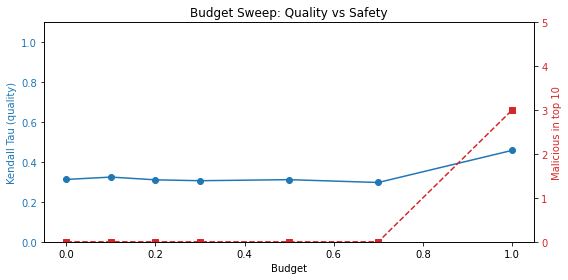

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 4))

color_tau = '#1f77b4'
color_mal = '#d62728'

ax1.set_xlabel('Budget')
ax1.set_ylabel('Kendall Tau (quality)', color=color_tau)
ax1.plot(budgets, sweep_tau, 'o-', color=color_tau, label='Tau')
ax1.tick_params(axis='y', labelcolor=color_tau)
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
ax2.set_ylabel('Malicious in top 10', color=color_mal)
ax2.plot(budgets, sweep_mal10, 's--', color=color_mal, label='Mal/10')
ax2.tick_params(axis='y', labelcolor=color_mal)
ax2.set_ylim(0, max(sweep_mal10) + 2)

ax1.set_title('Budget Sweep: Quality vs Safety')
fig.tight_layout()
plt.show()

## Summary

| | Base Retrieval | Naive Penalty | MOSAIC |
|---|---|---|---|
| **Approach** | Rank by embedding similarity | `relevance - 0.5 * risk` | Orthogonalize safety against relevance, then constrained projection |
| **Attack blocked?** | No (2 injected in top-3) | Yes (0 in top-10) | Yes (0 in top-10) |
| **Quality (tau)** | 1.000 (baseline) | 0.222 (61.1%) | 0.306 (65.3%) |
| **Recall@10** | 20% (8 of top-10 are injected) | 80% | 60% |
| **Control** | None | Weight parameter (fragile) | Budget knob (smooth) |

### Key takeaways

1. **Both methods block the attack.** In this scenario, the risk signal from PRRGate-style
   detection is strong enough that even naive subtraction removes all injected docs from
   the citation window. The difference is in collateral damage to ordering quality.

2. **MOSAIC preserves more pairwise orderings.** tau = 0.306 vs 0.222 means MOSAIC
   retains 4.2 percentage points more of the base retriever's ordering decisions. This
   matters because the base retriever's ordering of *safe* documents is valuable — it
   reflects genuine relevance to the query.

3. **The quality gap is moderate, not dramatic.** This is inherent to the adversarial
   RAG setting: when 8 of the top 10 documents are malicious, *any* effective defense
   must make large rank changes. The ceiling for quality retention is lower than in
   content moderation or fraud detection. MOSAIC's advantage is that it makes these
   changes more precisely.

4. **The budget sweep is flat.** The risk detector's signal is so clear that even
   budget = 0.70 blocks the attack. This is characteristic of strong binary safety
   signals — you don't need to sacrifice much quality to get safety. The budget knob
   matters more when the safety signal is noisy or continuous (like toxicity scores).

5. **Audit receipts show the mechanism.** Injected documents get negative orthogonalized
   steering scores and are displaced by +33.5 positions on average. Safe documents
   move up by -21.4 positions. The receipts make every ranking decision explainable.

```python
from mosaic import govern
result = govern(retrieval_scores, safety_scores, budget=0.30)
```